# LARRY Dataset: Preprocessing and EDA

Downloads the Weinreb 2020 LARRY in-vitro scRNA-seq data directly from the Klein Lab
server using `requests` (SSL verification disabled for this internal Harvard server).
Applies standard scanpy preprocessing: log1p → HVG → scale → PCA.
Saves processed AnnData for downstream trajectory methods.

## 1. Imports and Configuration

In [ ]:
%matplotlib inline

import sys, importlib, warnings, pathlib
import numpy as np
import pandas as pd
import scipy.io, scipy.sparse
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata

warnings.filterwarnings('ignore')
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor='white')

DATA_DIR = pathlib.Path('KleinLabData')
OUTPUT_H5AD = 'larry_preprocessed.h5ad'
N_HVG = 2000
N_PCS = 50

time_col     = 'Time point'
celltype_col = 'Cell type annotation'
well_col     = 'Well'
clone_col    = 'clone_idx'

for pkg in ['scanpy', 'anndata', 'scipy', 'numpy', 'pandas']:
    m = importlib.import_module(pkg)
    print(f'  {pkg}: {getattr(m, "__version__", "ok")}')

  scanpy: 1.12.1
  anndata: 0.10.9
  scipy: 1.17.1
  numpy: 2.4.6
  pandas: 2.3.3


## 2a. Download Raw Data

Four files from the Klein Lab state-fate website. The server uses an intermediate
CA not in Python's Windows CA store; `verify=False` with urllib3 warning suppressed.

In [ ]:
import requests, urllib3
urllib3.disable_warnings()

BASE  = 'https://kleintools.hms.harvard.edu/paper_websites/state_fate2020/'
FILES = [
    'stateFate_inVitro_gene_names.txt.gz',
    'stateFate_inVitro_normed_counts.mtx.gz',
    'stateFate_inVitro_metadata.txt.gz',
    'stateFate_inVitro_clone_matrix.mtx.gz',
]
DATA_DIR.mkdir(exist_ok=True)

def download_with_resume(url, fpath):
    existing = fpath.stat().st_size if fpath.exists() else 0
    head = requests.head(url, verify=False, timeout=15)
    total = int(head.headers.get('content-length', 0))
    if existing and total and existing >= total:
        print(f'  OK  {fpath.name}  ({existing/1e6:.1f} MB)')
        return
    headers = {'Range': f'bytes={existing}-'} if existing else {}
    mode = 'ab' if existing else 'wb'
    label = 'Resuming' if existing else 'Downloading'
    print(f'  {label} {fpath.name}  ({(total-existing)/1e6:.1f} MB to go) ...')
    # Can set timeout=None if connection is temporarily stalling
    r = requests.get(url, verify=False, stream=True, timeout=(30, 600), headers=headers)
    r.raise_for_status()
    with open(fpath, mode) as f:
        for chunk in r.iter_content(1 << 17):
            f.write(chunk)
    print(f'    -> {fpath.stat().st_size/1e6:.1f} MB total')

for fname in FILES:
    download_with_resume(BASE + fname, DATA_DIR / fname)

print('All files present.')

## 2b. (Alternative) Load via CoSpar built-in dataloader

Downloads a single pre-processed ~150 MB h5ad from the Westlake University mirror — much
faster than pulling ~2 GB of raw MTX files and re-running the full pipeline.

**Limitations vs. the raw 2a pipeline:**
- Only the 49k *cloned* cells are included (full dataset is 130k)
- No `Well` column → no Weinreb 2020 train/test split (`fate_train`/`fate_test` are all True/False)
- No raw expression layers (`counts_norm`, `log1p_norm`) — PRESCIENT notebook requires these
- CoSpar uses its own HVG/PCA embedding, not the scanpy pipeline in sections 3–5

The cell remaps CoSpar's column names to match what notebooks 02–04 expect, so downstream
analysis will run without errors, but results may differ from the raw-pipeline baseline.

In [ ]:
# pip install cospar  (if not already installed)
import cospar as cs
import numpy as np
import scipy.sparse

cs.settings.data_path  = "KleinLabData"
cs.settings.figure_path = "figures"

adata = cs.datasets.hematopoiesis()

# --- Remap CoSpar schema to match downstream notebook conventions ---

# Time: CoSpar stores strings '2'/'4'/'6'; notebooks expect float
adata.obs['Time point'] = adata.obs['time_info'].astype(float)

# Cell type: CoSpar abbreviated names → Weinreb 2020 names
STATE_MAP = {
    'undiff':      'Undifferentiated',
    'Neutrophil':  'Neutrophil',
    'Monocyte':    'Monocyte',
    'Baso':        'Baso',
    'Mast':        'Mast',
    'Meg':         'Meg',
    'Erythroid':   'Erythroid',
    'Lymphoid':    'Lymphoid',
    'Eos':         'Eos',
    'Neu_Mon':     None,   # ambiguous progenitor — leave unlabeled
}
adata.obs['Cell type annotation'] = adata.obs['state_info'].map(STATE_MAP)

# clone_idx: every cell in CoSpar is cloned; take first nonzero column per row
X_clone = adata.obsm['X_clone']
if not scipy.sparse.issparse(X_clone):
    X_clone = scipy.sparse.csr_matrix(X_clone)
nz_rows, nz_cols = X_clone.nonzero()
clone_idx = np.full(adata.n_obs, -1, dtype=int)
for r, c in zip(nz_rows, nz_cols):
    if clone_idx[r] == -1:
        clone_idx[r] = c
adata.obs['clone_idx'] = clone_idx

# Well: CoSpar doesn't carry this — assign 0 for all.
# NOTE: fate_train/fate_test splits used by downstream notebooks will not reflect
# the original Weinreb 2020 Well-based split; all cells will appear as "train".
adata.obs['Well'] = 0

# UMAP: CoSpar stores embedding as X_emb
adata.obsm['X_umap'] = adata.obsm['X_emb']

# fate_frac_*: map CoSpar progenitor columns (day-2 fate probabilities)
PROG_TO_FATE = {
    'progenitor_Ccr7_DC':   'fate_frac_Ccr7_DC',
    'progenitor_Mast':      'fate_frac_Mast',
    'progenitor_Meg':       'fate_frac_Meg',
    'progenitor_pDC':       'fate_frac_pDC',
    'progenitor_Eos':       'fate_frac_Eos',
    'progenitor_Lymphoid':  'fate_frac_Lymphoid',
    'progenitor_Erythroid': 'fate_frac_Erythroid',
    'progenitor_Baso':      'fate_frac_Baso',
    'progenitor_Neutrophil':'fate_frac_Neutrophil',
    'progenitor_Monocyte':  'fate_frac_Monocyte',
}
for src, dst in PROG_TO_FATE.items():
    if src in adata.obs.columns:
        adata.obs[dst] = adata.obs[src]

print("WARNING: CoSpar 2b path — 49k cloned cells only (full dataset is 130k).")
print("No Well-based train/test split. layers (counts_norm/log1p_norm) not available.")
print()
print(adata)
print("obs columns:", list(adata.obs.columns))

OUTPUT_H5AD = "larry_preprocessed.h5ad"
adata.write_h5ad(OUTPUT_H5AD)
print(f"\nSaved to {OUTPUT_H5AD} — skip sections 2a/3–8 and go directly to notebook 02.")

> **Note:** Verify the exact function name (`cs.datasets.hematopoiesis()`) against
> your installed CoSpar version — it may also appear as `hematopoiesis_inVitro()`.
> Run `dir(cs.datasets)` to list available loaders.

## 3. Assemble AnnData

In [2]:
import gzip

RAW_CACHE = pathlib.Path('larry_raw.h5ad')

if RAW_CACHE.exists():
    print(f'Loading cached raw AnnData from {RAW_CACHE} ...')
    adata = anndata.read_h5ad(RAW_CACHE)
else:
    # Gene names
    with gzip.open(DATA_DIR / 'stateFate_inVitro_gene_names.txt.gz', 'rt') as fh:
        gene_names = [l.strip() for l in fh if l.strip()]
    var = pd.DataFrame(index=gene_names)
    var.index.name = 'gene_ids'
    print(f'Genes: {len(gene_names)}')

    # Cell metadata
    obs = pd.read_csv(DATA_DIR / 'stateFate_inVitro_metadata.txt.gz', sep='\t')
    obs.index = obs.index.astype(str)
    print(f'Cells: {len(obs)}')

    # Expression matrix (Klein Lab normed_counts: cells x genes)
    print('Loading expression matrix (~2 GB MTX, ~2 min) ...')
    X_raw = scipy.io.mmread(DATA_DIR / 'stateFate_inVitro_normed_counts.mtx.gz')
    X = scipy.sparse.csr_matrix(X_raw)
    if X.shape[0] == len(gene_names) and X.shape[1] == len(obs):
        X = X.T
    print(f'X shape: {X.shape}  (cells x genes)')

    # Clone matrix
    X_clone_raw = scipy.io.mmread(DATA_DIR / 'stateFate_inVitro_clone_matrix.mtx.gz')
    X_clone = scipy.sparse.csr_matrix(X_clone_raw)
    if X_clone.shape[0] != X.shape[0]:
        X_clone = X_clone.T
    print(f'Clone matrix: {X_clone.shape}')

    adata = anndata.AnnData(X=X, obs=obs, var=var)
    adata.obsm['X_clone'] = X_clone

    # clone_idx: -1 for uncloned cells, clone column index otherwise
    nz_rows, nz_cols = X_clone.nonzero()
    clone_idx = np.full(adata.n_obs, -1, dtype=int)
    for r, c in zip(nz_rows, nz_cols):
        if clone_idx[r] == -1:
            clone_idx[r] = c
    adata.obs[clone_col] = clone_idx

    print('Saving raw cache ...')
    adata.write_h5ad(RAW_CACHE)

print()
print(adata)
print('\nobs columns:', list(adata.obs.columns))

Loading cached raw AnnData from larry_raw.h5ad ...

AnnData object with n_obs × n_vars = 130887 × 25289
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx'
    obsm: 'X_clone'

obs columns: ['Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx']


## 4. Raw Data EDA

**Note:** The Klein Lab ships `normed_counts.mtx.gz` - counts are already
library-size normalized before they reach our pipeline (sum per cell ≈ 2879,
constant across all cells).  "Raw" here means pre-log, pre-HVG, pre-scale
relative to *our* steps below.  Total counts per cell are therefore
uninformative; we plot genes-detected and expression quantiles instead.

In [7]:
print(f'Cells: {adata.n_obs:,}   Genes: {adata.n_vars:,}')

if time_col in adata.obs:
    print('\nCells per time point:')
    print(adata.obs[time_col].value_counts().sort_index())

if well_col in adata.obs:
    print('\nCells per well:')
    print(adata.obs[well_col].value_counts().sort_index())

has_clone = (adata.obs[clone_col] >= 0)
print(f'\nCells with clone assignment: {has_clone.sum():,} / {adata.n_obs:,} ({100*has_clone.mean():.1f}%)')

Cells: 130,887   Genes: 25,289

Cells per time point:
Time point
2.0    28249
4.0    48498
6.0    54140
Name: count, dtype: int64

Cells per well:
Well
0    28249
1    45811
2    56827
Name: count, dtype: int64

Cells with clone assignment: 49,302 / 130,887 (37.7%)


Total counts per cell: constant at 2878.7 (library-size normalised)
Genes detected — median: 1215, range: 178–5633


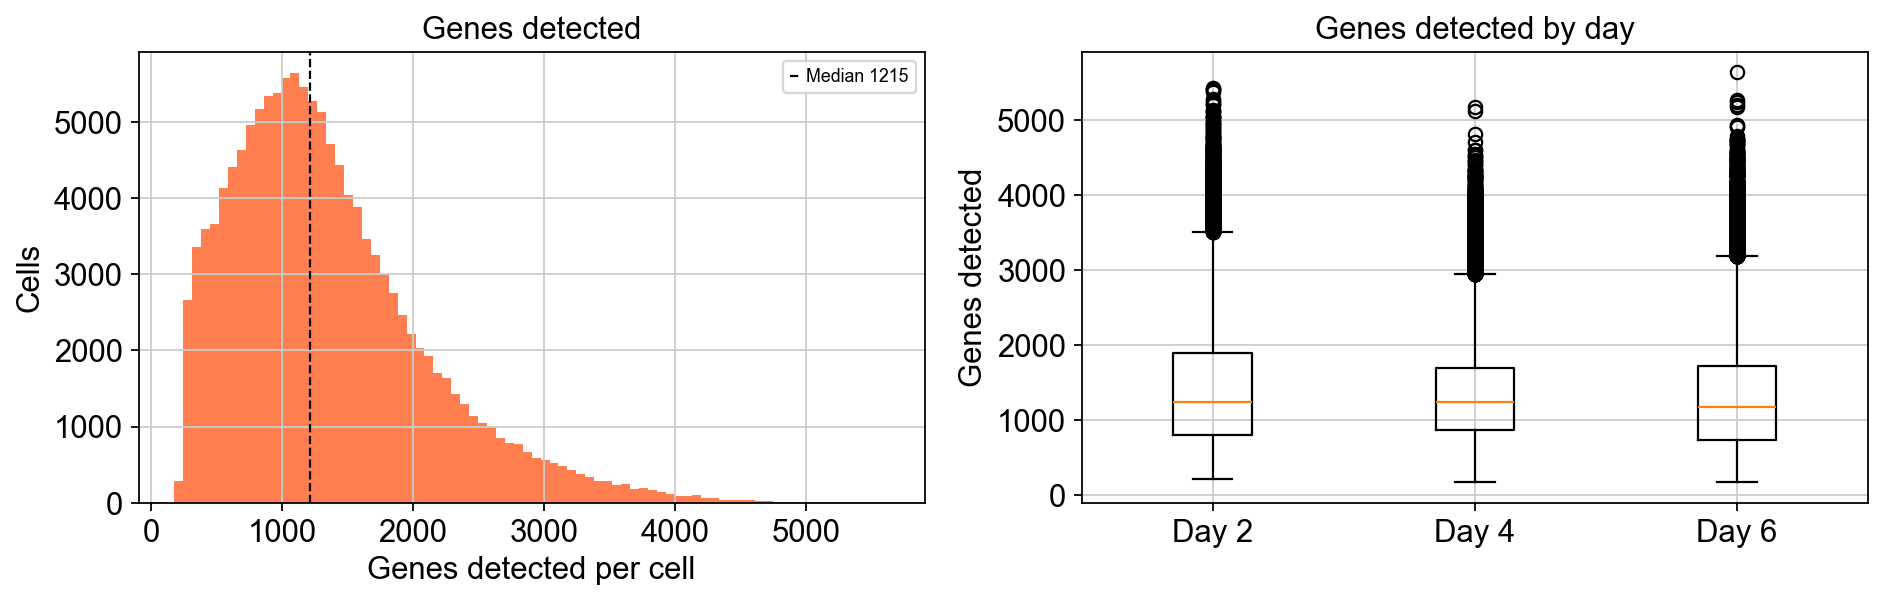

In [ ]:
# total_counts is constant per cell (Klein Lab normalization) - not plotted
total_counts = np.asarray(adata.X.sum(axis=1)).ravel()
n_genes_det  = np.asarray((adata.X > 0).sum(axis=1)).ravel()
adata.obs['total_counts'] = total_counts
adata.obs['n_genes_detected'] = n_genes_det

print(f'Total counts per cell: constant at {total_counts[0]:.1f} (library-size normalised)')
print(f'Genes detected - median: {np.median(n_genes_det):.0f}, '
      f'range: {n_genes_det.min()}-{n_genes_det.max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Genes detected per cell
axes[0].hist(n_genes_det, bins=80, color='coral', edgecolor='none')
axes[0].set(xlabel='Genes detected per cell', ylabel='Cells', title='Genes detected')
axes[0].axvline(np.median(n_genes_det), color='k', ls='--', lw=1, label=f'Median {np.median(n_genes_det):.0f}')
axes[0].legend(fontsize=8)

# Genes detected by day
if time_col in adata.obs:
    time_vals = sorted(adata.obs[time_col].unique())
    axes[1].boxplot(
        [adata.obs.loc[adata.obs[time_col] == t, 'n_genes_detected'].values for t in time_vals],
        labels=[f'Day {int(t)}' for t in time_vals],
    )
    axes[1].set(ylabel='Genes detected', title='Genes detected by day')

plt.tight_layout()
plt.savefig('qc_raw.png', dpi=80, bbox_inches='tight')
plt.show()

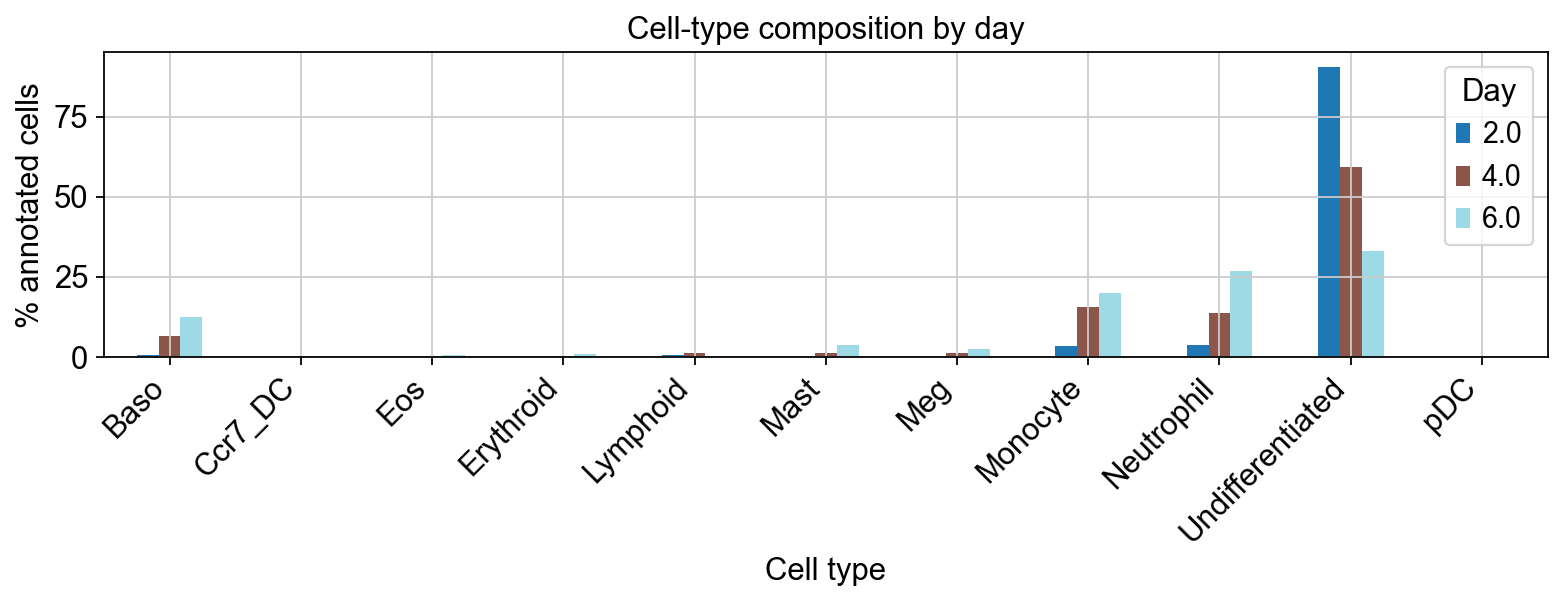

Cell type counts (all days):
Cell type annotation
Undifferentiated    72193
Neutrophil          22237
Monocyte            19182
Baso                10155
Mast                 2584
Meg                  2096
Lymphoid              857
Erythroid             686
Eos                   555
Ccr7_DC               241
pDC                   101
Name: count, dtype: int64


In [9]:
if celltype_col in adata.obs:
    ann = adata.obs[adata.obs[celltype_col].notna()]
    ct_pct = (ann.groupby([time_col, celltype_col]).size()
                .unstack(fill_value=0)
                .pipe(lambda df: df.div(df.sum(1), axis=0) * 100))

    fig, ax = plt.subplots(figsize=(10, 4))
    ct_pct.T.plot(kind='bar', ax=ax, colormap='tab20')
    ax.set(xlabel='Cell type', ylabel='% annotated cells', title='Cell-type composition by day')
    ax.legend(title='Day', bbox_to_anchor=(1,1))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('celltypes_raw.png', dpi=80, bbox_inches='tight')
    plt.show()
    print('Cell type counts (all days):')
    print(ann[celltype_col].value_counts())

## 5. Preprocessing Pipeline

The expression matrix is already normalized to 10k counts (Klein Lab `normed_counts`).
Pipeline: **log1p** → **HVG** (top 2000, seurat flavor) → **scale** (clip ±10 SD) → **PCA** (50 PCs)

In [10]:
# Store pre-log normalized counts
adata.layers['counts_norm'] = adata.X.copy()

# log1p
sc.pp.log1p(adata)
adata.layers['log1p_norm'] = adata.X.copy()
print('log1p done.')

# Highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG, flavor='seurat', subset=False)
n_hvg = adata.var['highly_variable'].sum()
print(f'HVG: {n_hvg:,} / {adata.n_vars:,} genes selected (top {N_HVG})')

# Optional PRESCIENT extras are computed in a dedicated cell below.
# Keep placeholders so the default workflow (non-PRESCIENT notebooks) is unchanged.
cc_marker_expr = None
cc_marker_genes = []
print('Default preprocessing complete (PRESCIENT extras not yet computed).')

log1p done.
HVG: 2,000 / 25,289 genes selected (top 2000)


## 5b. Optional: PRESCIENT support metadata

Run the next cell **only if** you plan to run `03_prescient.ipynb` from a freshly generated preprocessing file.

This is additive-only:
- computes cell-cycle scores on the full gene set and stores them in `obs`
- stores a cell-cycle marker expression matrix in `obsm['X_cellcycle']`
- does **not** change HVG selection, `X`, `X_pca`, or `X_umap` used by other notebooks

In [ ]:
# Optional PRESCIENT support metadata (additive-only; does NOT change HVGs/PCA/UMAP)
ENABLE_PRESCIENT_EXTRAS = False  # set True only when preparing data for 03_prescient.ipynb

if ENABLE_PRESCIENT_EXTRAS:
    CYCLING_GENES = ['Mki67', 'Top2a', 'Pcna']
    CELL_CYCLE_GENES_NB03 = ['Ube2c', 'Hmgb2', 'Hmgn2', 'Tuba1b', 'Ccnb1', 'Tubb5', 'Top2a', 'Tubb4b']
    S_PHASE_GENES = [
        'MCM5', 'PCNA', 'TYMS', 'FEN1', 'MCM2', 'MCM4', 'RRM1', 'UNG', 'GINS2',
        'MCM6', 'CDCA7', 'DTL', 'PRIM1', 'UHRF1', 'HELLS', 'RFC2', 'RPA2', 'NASP',
        'RAD51AP1', 'GMNN', 'WDR76', 'SLBP', 'CCNE2', 'UBR7', 'POLD3', 'MSH2',
        'ATAD2', 'RAD51', 'RRM2', 'CDC45', 'CDC6', 'EXO1', 'TIPIN', 'DSCC1', 'BLM',
        'CASP8AP2', 'USP1', 'CLSPN', 'POLA1', 'CHAF1B', 'BRIP1', 'E2F8',
    ]
    G2M_GENES = [
        'HMGB2', 'CDK1', 'NUSAP1', 'UBE2C', 'BIRC5', 'TPX2', 'TOP2A', 'NDC80',
        'CKS2', 'NUF2', 'CKS1B', 'MKI67', 'TMPO', 'CENPF', 'TACC3', 'FAM64A',
        'SMC4', 'CCNB2', 'CKAP2L', 'CKAP2', 'AURKB', 'BUB1', 'KIF11', 'ANP32E',
        'TUBB4B', 'GTSE1', 'KIF20B', 'HJURP', 'CDCA3', 'HN1', 'CDC20', 'TTK',
        'CDC25C', 'KIF2C', 'RANGAP1', 'NCAPD2', 'DLGAP5', 'CDCA2', 'CDCA8', 'ECT2',
        'KIF23', 'HMMR', 'AURKA', 'PSRC1', 'ANLN', 'LBR', 'CKAP5', 'CENPE', 'CTCF',
        'NEK2', 'G2E3', 'GAS2L3', 'CBX5', 'CENPA',
    ]

    _name_map = {str(n).lower(): str(n) for n in adata.var_names}
    def _resolve(names):
        return [_name_map[g.lower()] for g in names if g.lower() in _name_map]

    s_found = _resolve(S_PHASE_GENES)
    g2m_found = _resolve(G2M_GENES)
    print(f'Cell-cycle genes resolved in full matrix: {len(s_found)} S-phase, {len(g2m_found)} G2M')
    assert len(s_found) >= 2 and len(g2m_found) >= 2, (
        'Standard cell-cycle genes not found in the full var_names — check gene naming.'
    )

    sc.tl.score_genes_cell_cycle(adata, s_genes=s_found, g2m_genes=g2m_found)
    adata.obs['proliferation_score'] = adata.obs[['S_score', 'G2M_score']].max(axis=1)
    print(
        "Added obs columns S_score / G2M_score / phase / proliferation_score "
        f"(proliferation_score std={adata.obs['proliferation_score'].std():.3f})"
    )
    print('Phase counts:', adata.obs['phase'].value_counts().to_dict())

    cc_marker_genes = sorted(set(_resolve(S_PHASE_GENES + G2M_GENES + CYCLING_GENES + CELL_CYCLE_GENES_NB03)))
    _cc_idx_full = [adata.var_names.get_loc(g) for g in cc_marker_genes]
    cc_marker_expr = adata.layers['log1p_norm'][:, _cc_idx_full]
    if scipy.sparse.issparse(cc_marker_expr):
        cc_marker_expr = np.asarray(cc_marker_expr.todense())
    else:
        cc_marker_expr = np.asarray(cc_marker_expr)
    print(
        f'Captured {len(cc_marker_genes)} cell-cycle marker genes for obsm["X_cellcycle"] '
        f'(HVG/PCA/UMAP unchanged).'
    )
else:
    print('Skipping optional PRESCIENT extras (ENABLE_PRESCIENT_EXTRAS=False).')

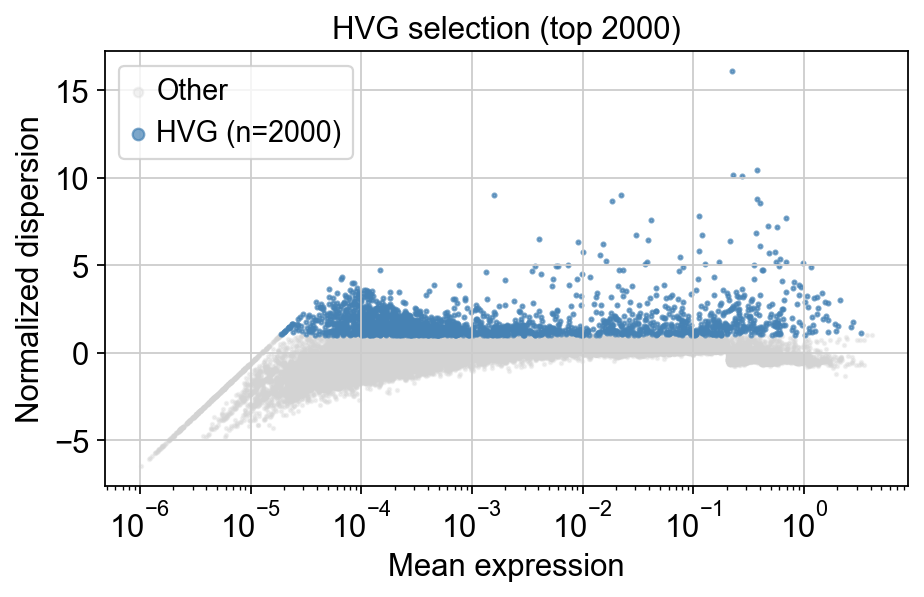

In [11]:
# HVG dispersion plot
fig, ax = plt.subplots(figsize=(6, 4))
means  = adata.var['means']
disps  = adata.var['dispersions_norm']
is_hvg = adata.var['highly_variable'].values
ax.scatter(means[~is_hvg], disps[~is_hvg], s=2, alpha=0.3, color='lightgray', label='Other')
ax.scatter(means[is_hvg],  disps[is_hvg],  s=3, alpha=0.7, color='steelblue', label=f'HVG (n={is_hvg.sum()})')
ax.set(xscale='log', xlabel='Mean expression', ylabel='Normalized dispersion',
       title=f'HVG selection (top {N_HVG})')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('hvg_dispersion.png', dpi=80, bbox_inches='tight')
plt.show()

In [12]:
# Subset to HVGs, scale, PCA
adata_proc = adata[:, adata.var['highly_variable']].copy()
adata_proc.layers['log1p_norm'] = adata.layers['log1p_norm'][:, adata.var['highly_variable'].values]
print(f'Processing {adata_proc.n_vars:,} HVGs x {adata_proc.n_obs:,} cells')

sc.pp.scale(adata_proc, max_value=10)
print('Scaling done.')

sc.pp.pca(adata_proc, n_comps=N_PCS, svd_solver='arpack')
print(f'PCA done: {adata_proc.obsm["X_pca"].shape}')

# Copy PCA back to full adata for reference
adata.obsm['X_pca'] = adata_proc.obsm['X_pca']
adata.uns['pca'] = adata_proc.uns.get('pca', {})

# Optional additive cell-cycle marker expression for PRESCIENT (notebook 03).
# Only attached if the dedicated PRESCIENT extras cell was run.
if cc_marker_expr is not None and len(cc_marker_genes) > 0:
    adata_proc.obsm['X_cellcycle'] = cc_marker_expr
    adata_proc.uns['cellcycle_genes'] = list(cc_marker_genes)
    print(f'Stored obsm["X_cellcycle"] {adata_proc.obsm["X_cellcycle"].shape} + uns["cellcycle_genes"].')
else:
    print('Skipping PRESCIENT extras attachment (run optional PRESCIENT cell to enable).')

Processing 2,000 HVGs x 130,887 cells
Scaling done.
PCA done: (130887, 50)


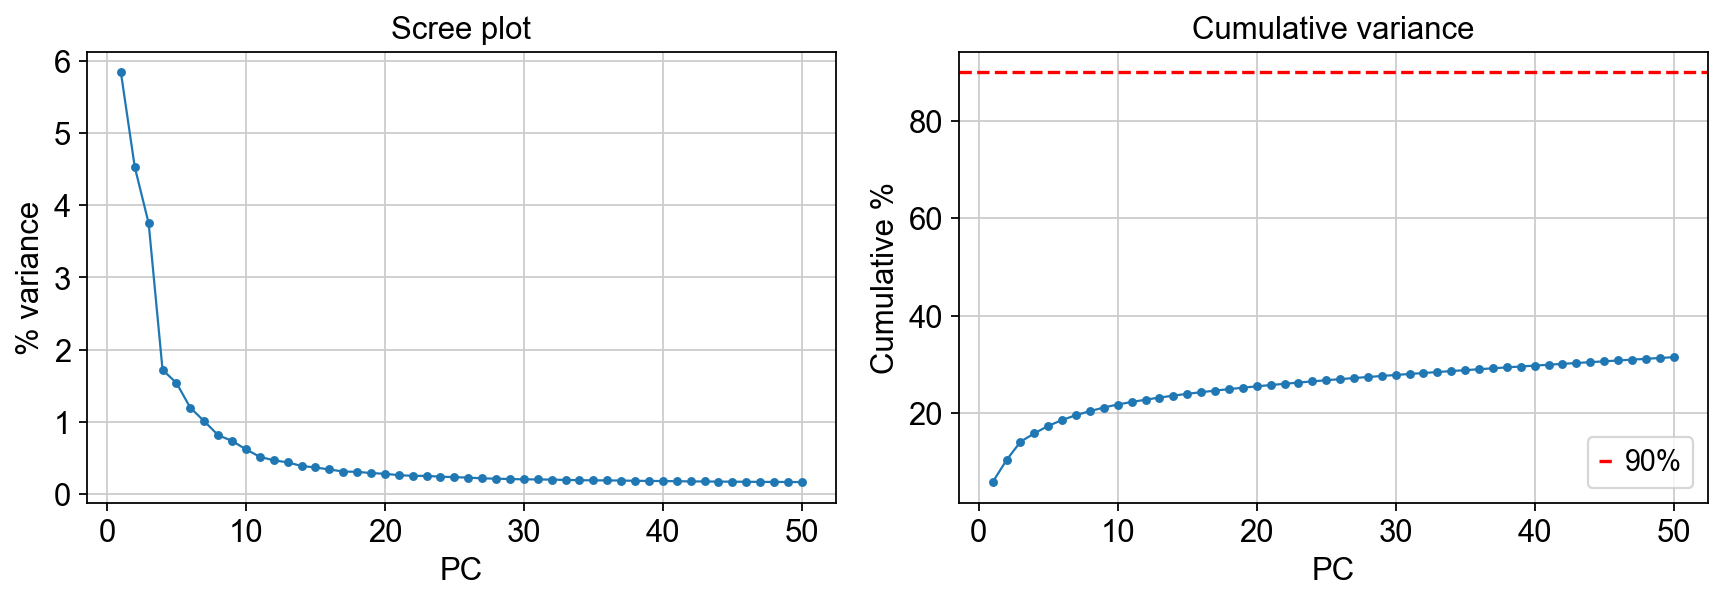

90% variance not reached within 50 PCs
Top-50 PCs explain: 31.5%


In [21]:
var_ratio = adata_proc.uns['pca']['variance_ratio']
cum_var = np.cumsum(var_ratio)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, len(var_ratio)+1), var_ratio*100, 'o-', ms=3, lw=1)
axes[0].set(xlabel='PC', ylabel='% variance', title='Scree plot')

axes[1].plot(range(1, len(cum_var)+1), cum_var*100, 'o-', ms=3, lw=1)
axes[1].axhline(90, color='red', ls='--', label='90%')
axes[1].set(xlabel='PC', ylabel='Cumulative %', title='Cumulative variance')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_scree.png', dpi=80, bbox_inches='tight')
plt.show()

idx90 = np.searchsorted(cum_var, 0.90)
if idx90 < len(cum_var):
    print(f'PCs for 90% variance: {idx90 + 1}')
else:
    print(f'90% variance not reached within {len(cum_var)} PCs')
print(f'Top-{len(cum_var)} PCs explain: {100*cum_var[-1]:.1f}%')

> **Note:** Could experiment with fewer number of principal components

## 6. UMAP

In [14]:
print('Computing k-NN graph ...')
sc.pp.neighbors(adata_proc, n_neighbors=30, n_pcs=N_PCS)
print('Computing UMAP ...')
sc.tl.umap(adata_proc, random_state=42)
adata.obsm['X_umap'] = adata_proc.obsm['X_umap']
print('Done.')

Computing k-NN graph ...
Computing UMAP ...
Done.


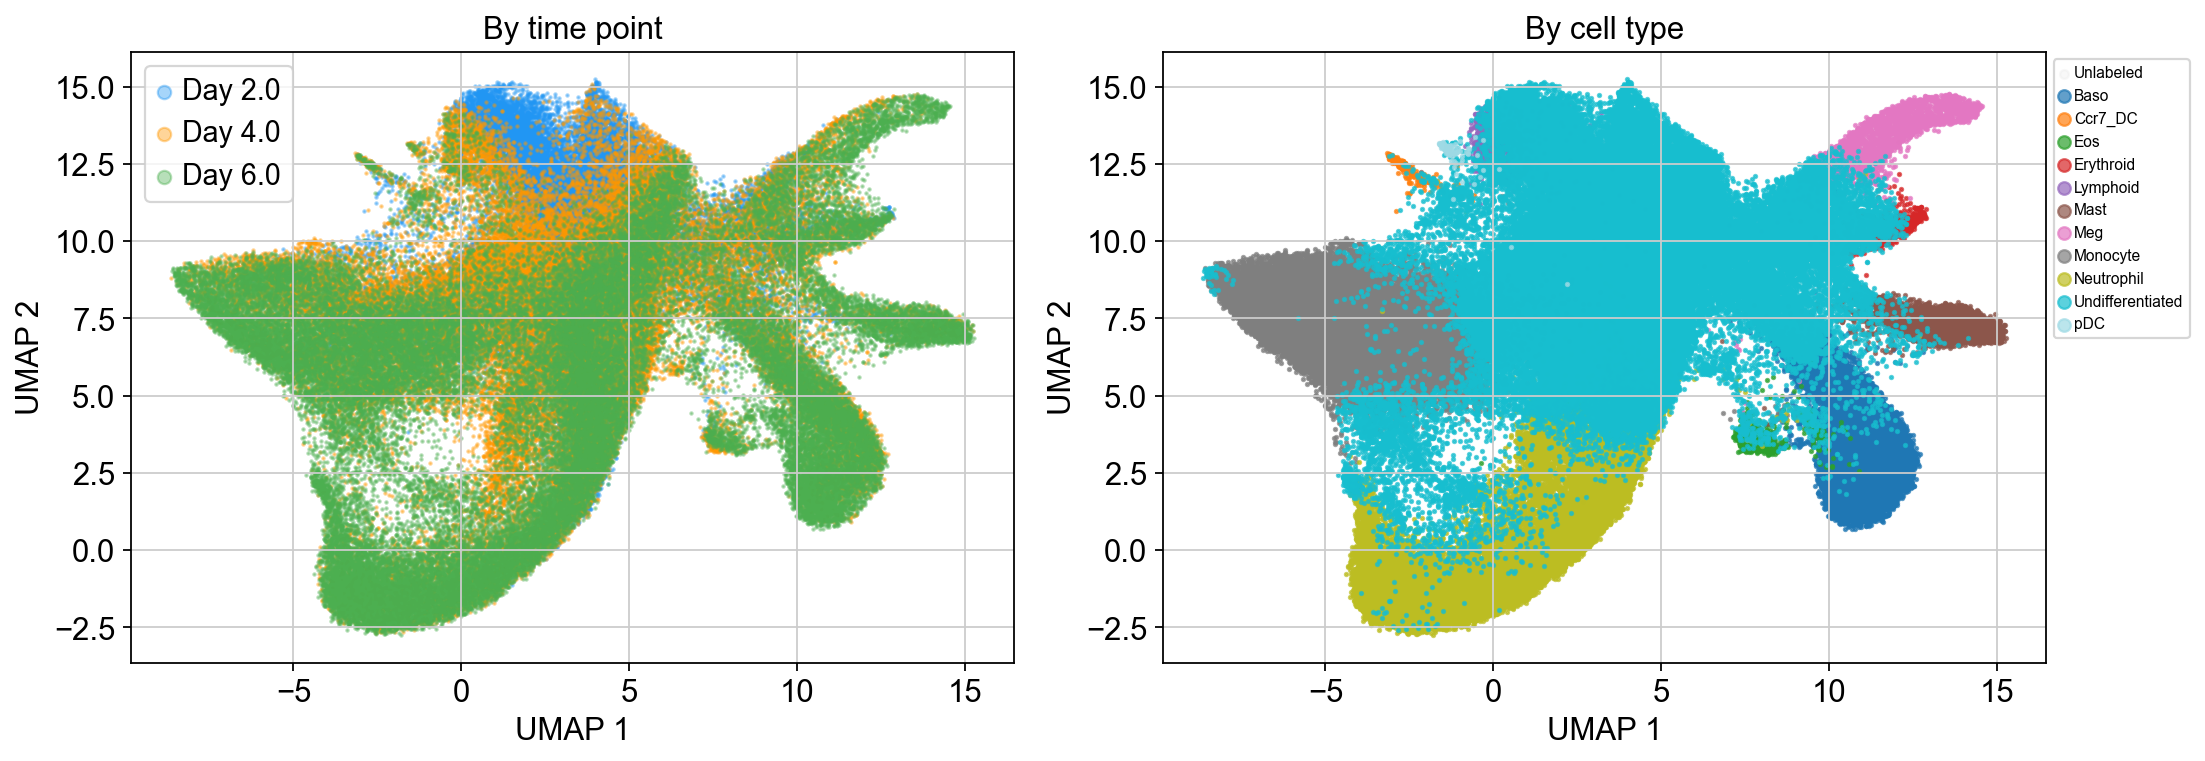

In [ ]:
umap = adata_proc.obsm['X_umap']
time_vals = sorted(adata.obs[time_col].unique())
day_colors = dict(zip(time_vals, ['#2196F3', '#FF9800', '#4CAF50']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By day
for t in time_vals:
    m = (adata.obs[time_col] == t).values
    axes[0].scatter(umap[m, 0], umap[m, 1], s=1, alpha=0.4, color=day_colors[t], label=f'Day {t}')
axes[0].set(xlabel='UMAP 1', ylabel='UMAP 2', title='By time point')
axes[0].legend(markerscale=6)

# By cell type
if celltype_col in adata.obs:
    cts = sorted(adata.obs[celltype_col].dropna().unique())
    cmap = plt.get_cmap('tab20', len(cts))
    unlab = adata.obs[celltype_col].isna().values
    axes[1].scatter(umap[unlab, 0], umap[unlab, 1], s=1, alpha=0.15, color='lightgray', label='Unlabeled')
    for i, ct in enumerate(cts):
        m = (adata.obs[celltype_col] == ct).values
        axes[1].scatter(umap[m, 0], umap[m, 1], s=2, alpha=0.7, color=cmap(i), label=ct)
    axes[1].set(xlabel='UMAP 1', ylabel='UMAP 2', title='By cell type')
    axes[1].legend(markerscale=4, bbox_to_anchor=(1, 1), fontsize=7)

plt.tight_layout()
plt.savefig('umap_overview.png', dpi=80, bbox_inches='tight')
plt.show()

## 7. Fate annotation and train/test split

`Well` 0–1 = training set; `Well` 2 = held-out test set (PRESCIENT/Weinreb 2020 convention).
Fate labels come from clonal lineage tracing on day-2 cells.

In [ ]:
obs_d2 = adata.obs[adata.obs[time_col] == 2]
cloned_d2 = (obs_d2[clone_col] >= 0).sum()
print(f'Day-2 cells: {len(obs_d2):,}')
print(f'With clone assignment: {cloned_d2:,} ({100*cloned_d2/len(obs_d2):.1f}%)')

if well_col in adata.obs:
    adata.obs['fate_train'] = adata.obs[well_col].isin([0, 1])
    adata.obs['fate_test'] = adata.obs[well_col] == 2
    print('\nFate split:')
    print(adata.obs.groupby(time_col)[['fate_train', 'fate_test']].sum())

for col in ['fate_train', 'fate_test', clone_col, time_col, celltype_col, well_col,
            'total_counts', 'n_genes_detected']:
    if col in adata.obs and col not in adata_proc.obs:
        adata_proc.obs[col] = adata.obs[col].values

Day-2 cells: 28,249
With clone assignment: 4,638 (16.4%)

Fate split:
            fate_train  fate_test
Time point                       
2.0              28249          0
4.0              21300      27198
6.0              24511      29629


## 7b. Clonal fate fractions for day-2 cells

For each day-2 cell with a clone assignment, follow that clone forward to days 4/6 and
record the fraction of its descendants in each cell type.  These `fate_frac_*` columns
are the ground-truth labels used by Palantir (and other single-snapshot methods) to
evaluate predicted fate probabilities.

In [ ]:
print("Computing clonal fate fractions for day-2 cells...")

# Collect all later-day cells that belong to a tracked clone
later_mask = (adata.obs[time_col] > 2) & (adata.obs[clone_col] >= 0)
later_df = adata.obs.loc[later_mask, [clone_col, celltype_col]].copy()
later_df = later_df[later_df[celltype_col].notna()]

# fate_table: rows = clone_idx, cols = cell types, values = count
fate_table = (
    later_df.groupby([clone_col, celltype_col]).size()
    .unstack(fill_value=0)
)
fate_frac = fate_table.div(fate_table.sum(axis=1), axis=0)

# Sanitize column names for h5ad compatibility
fate_cols = [
    f"fate_frac_{ct.replace(' ', '_').replace('/', '_')}"
    for ct in fate_frac.columns
]
fate_frac.columns = fate_cols

# Assign to day-2 cells in adata_proc; all other cells stay NaN
for col in fate_cols:
    adata_proc.obs[col] = np.nan

d2_proc = adata_proc.obs[adata_proc.obs[time_col] == 2][[clone_col]].copy()
d2_merged = d2_proc.merge(fate_frac, left_on=clone_col, right_index=True, how='left')
for col in fate_cols:
    adata_proc.obs.loc[d2_merged.index, col] = d2_merged[col].values

n_with_fate = adata_proc.obs.loc[
    adata_proc.obs[time_col] == 2, fate_cols[0]
].notna().sum()
n_day2 = (adata_proc.obs[time_col] == 2).sum()
print(f"Day-2 cells with fate fractions: {n_with_fate:,} / {n_day2:,}")
print(f"Lineages tracked ({len(fate_cols)}): {[c.replace('fate_frac_', '') for c in fate_cols]}")

Computing clonal fate fractions for day-2 cells...
Day-2 cells with fate fractions: 2,621 / 28,249
Lineages tracked (11): ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Lymphoid', 'Mast', 'Meg', 'Monocyte', 'Neutrophil', 'Undifferentiated', 'pDC']


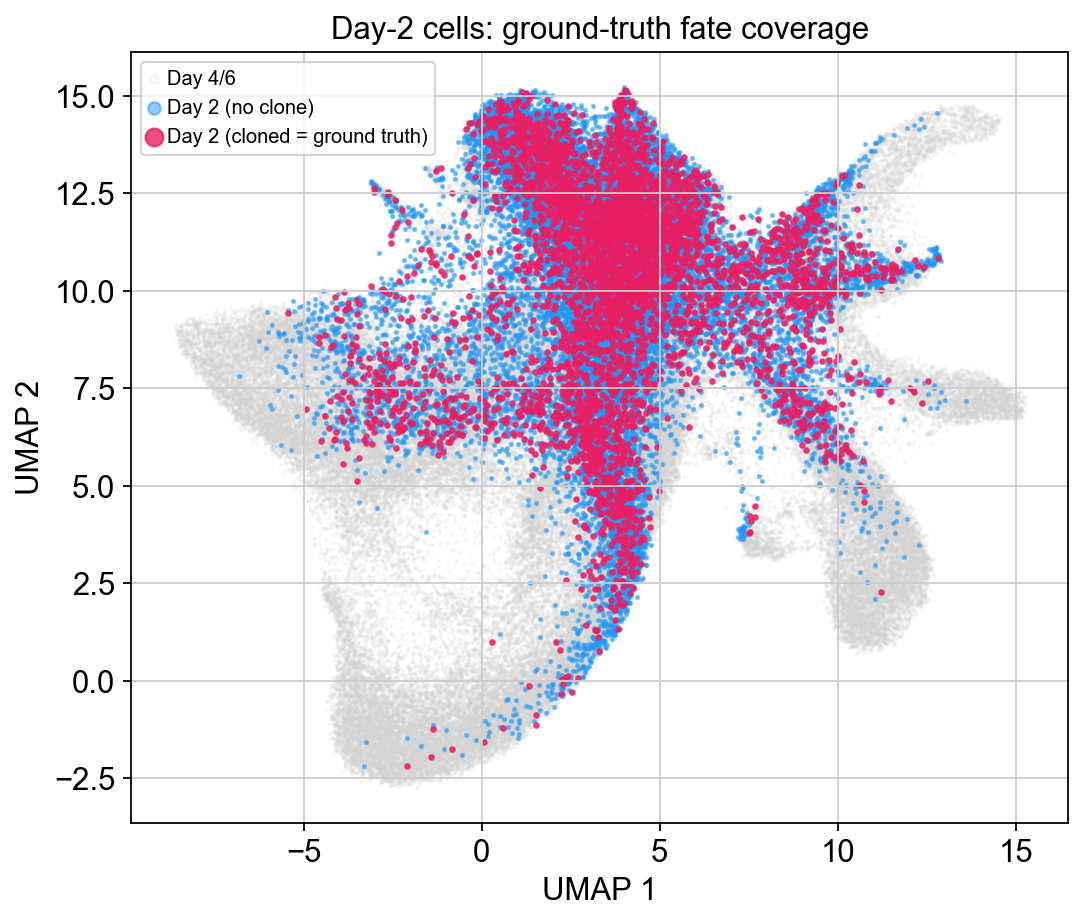

In [ ]:
is_d2 = (adata.obs[time_col] == 2).values
is_cloned = (adata.obs[clone_col] >= 0).values

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(umap[~is_d2, 0], umap[~is_d2, 1], s=1, alpha=0.15, color='lightgray', label='Day 4/6')
ax.scatter(umap[is_d2 & ~is_cloned, 0], umap[is_d2 & ~is_cloned, 1], s=2, alpha=0.5, color='#2196F3', label='Day 2 (no clone)')
ax.scatter(umap[is_d2 & is_cloned,  0], umap[is_d2 & is_cloned,  1], s=4, alpha=0.8, color='#E91E63', label='Day 2 (cloned = ground truth)')
ax.set(xlabel='UMAP 1', ylabel='UMAP 2', title='Day-2 cells: ground-truth fate coverage')
ax.legend(markerscale=4, fontsize=9)
plt.tight_layout()
plt.savefig('umap_d2_clones.png', dpi=80, bbox_inches='tight')
plt.show()

## 8. Save

In [20]:
print(adata_proc)
print(f'\nSaving to {OUTPUT_H5AD} ...')
adata_proc.write_h5ad(OUTPUT_H5AD)
print('Done.')

print('=' * 50)
print('PREPROCESSING COMPLETE')
print('=' * 50)
print(f'  Cells:       {adata_proc.n_obs:,}')
print(f'  HVGs used:   {adata_proc.n_vars:,}')
print(f'  PCA comps:   {adata_proc.obsm["X_pca"].shape[1]}')
print(f'  Output:      {OUTPUT_H5AD}')
print(f'  Layers:      {list(adata_proc.layers.keys())}')
print(f'  obsm keys:   {list(adata_proc.obsm.keys())}')

AnnData object with n_obs × n_vars = 130887 × 2000
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'total_counts', 'n_genes_detected', 'fate_train', 'fate_test', 'fate_frac_Baso', 'fate_frac_Ccr7_DC', 'fate_frac_Eos', 'fate_frac_Erythroid', 'fate_frac_Lymphoid', 'fate_frac_Mast', 'fate_frac_Meg', 'fate_frac_Monocyte', 'fate_frac_Neutrophil', 'fate_frac_Undifferentiated', 'fate_frac_pDC'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_clone', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts_norm', 'log1p_norm'
    obsp: 'distances', 'connectivities'

Saving to larry_preprocessed.h5ad ...
Done.
PREPROCESSING COMPLETE
  Cells:       130,887
  HVGs used:   2,000
  PCA comps:   50
  Output:      larry_preprocessed.h5ad
  Layers:      ['counts_norm', 'log1p_norm']
  obsm keys:   ['X_clone', 'X